# Coordenadas de las estaciones

* NE2 (Apodaca)	25.777222, -100.188056
* NE3 (Pesquería) 25.790556, -100.078333

# NDVI semanal para 500 metros alrededor de las estaciones

In [1]:
# Instalar una sola vez en el entorno del notebook si hace falta:
# %pip install pystac-client planetary-computer rasterio shapely pyproj pandas numpy matplotlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import planetary_computer
import rasterio
from pystac_client import Client
from rasterio.mask import mask
from shapely.geometry import Point, mapping
from shapely.ops import transform
from pyproj import Transformer


ESTACIONES = {
    "NE2": {"latitud": 25.777222, "longitud": -100.188056},
    "NE3": {"latitud": 25.790556, "longitud": -100.078333},
}
RADIO_BUFFER_METROS = 500
FECHA_INICIO = "2021-01-01"
FECHA_FIN = "2025-12-31"
MAX_NUBOSIDAD = 80


def ndvi_imagen_estacion(item, estacion):
    """Calcula la mediana del NDVI dentro del buffer para una imagen."""
    longitud = estacion["longitud"]
    latitud = estacion["latitud"]
    punto_wgs84 = Point(longitud, latitud)

    with rasterio.open(item.assets["B04"].href) as banda_roja:
        transformer = Transformer.from_crs(
            "EPSG:4326", banda_roja.crs, always_xy=True
        )
        punto_proyectado = transform(transformer.transform, punto_wgs84)
        area = punto_proyectado.buffer(RADIO_BUFFER_METROS)

        roja, _ = mask(banda_roja, [mapping(area)], crop=True, filled=False)

    with rasterio.open(item.assets["B08"].href) as banda_infrarroja:
        infrarroja, _ = mask(banda_infrarroja, [mapping(area)], crop=True, filled=False)

    roja = np.ma.asarray(roja[0], dtype="float32")
    infrarroja = np.ma.asarray(infrarroja[0], dtype="float32")
    mascara = np.ma.getmaskarray(roja) | np.ma.getmaskarray(infrarroja)
    roja = np.asarray(roja.filled(np.nan))
    infrarroja = np.asarray(infrarroja.filled(np.nan))
    denominador = infrarroja + roja

    ndvi = np.divide(
        infrarroja - roja,
        denominador,
        out=np.full_like(denominador, np.nan, dtype="float32"),
        where=(~mascara) & (denominador != 0),
    )
    valores_validos = ndvi[np.isfinite(ndvi)]

    if valores_validos.size == 0:
        return np.nan, 0

    return float(np.median(valores_validos)), int(valores_validos.size)


def semana_de(fecha):
    """Devuelve el lunes de la semana ISO a la que pertenece una fecha."""
    return pd.Timestamp(fecha).to_period("W-SUN").start_time

## Obtención y cálculo del NDVI semanal

El NDVI se obtuvo a partir de imágenes satelitales **Sentinel-2 Level-2A**, consultadas mediante el catálogo STAC público de Microsoft Planetary Computer. Este producto proporciona reflectancia de superficie, adecuada para calcular índices de vegetación.

Para cada estación se utilizó la coordenada registrada y se definió un área circular de **500 metros de radio**. El punto, originalmente expresado en longitud y latitud, se transformó al sistema de coordenadas de cada imagen antes de construir el buffer.

El NDVI se calculó para cada imagen usando la fórmula:

$$
NDVI = \frac{NIR - Rojo}{NIR + Rojo}
$$

En Sentinel-2, la banda **B08** representa el infrarrojo cercano (NIR) y la banda **B04** representa el rojo. Se descartaron los píxeles enmascarados o aquellos cuyo denominador fuera igual a cero.

Las imágenes (nubosidad menor al 80 %) se agrupan por **semana ISO** (semanas que inician en lunes). Para cada semana se calcula la mediana de los valores NDVI de todas las imágenes disponibles; si una semana no tiene imágenes válidas, `ndvi_mediana` queda como `NaN`.

El resultado contiene una fila por estación y semana, con las columnas `estacion`, `semana`, `ndvi_mediana`, `imagenes_utilizadas` y `pixeles_validos`. Los datos se guardan en `ndvi_semanal_estaciones_2020_2025.csv`.

In [2]:
catalogo = Client.open(
    "https://planetarycomputer.microsoft.com/api/stac/v1"
)

resultados_semanal = []
for nombre_estacion, estacion in ESTACIONES.items():
    punto = Point(estacion["longitud"], estacion["latitud"])
    punto_cercano = punto.buffer(0.01)

    busqueda = catalogo.search(
        collections=["sentinel-2-l2a"],
        intersects=mapping(punto_cercano),
        datetime=f"{FECHA_INICIO}/{FECHA_FIN}",
        query={"eo:cloud_cover": {"lt": MAX_NUBOSIDAD}},
    )

    items_por_semana = {}
    for item in busqueda.item_collection():
        semana = semana_de(item.datetime)
        items_por_semana.setdefault(semana, []).append(item)

    for semana in pd.date_range(FECHA_INICIO, FECHA_FIN, inclusive="left", freq="W-MON"):
        items = sorted(
            items_por_semana.get(semana, []),
            key=lambda item: item.properties.get("eo:cloud_cover", 100),
        )

        ndvi_imagenes = []
        pixeles_validos = 0
        for item in items:
            item = planetary_computer.sign(item)
            ndvi_imagen, cantidad_pixeles = ndvi_imagen_estacion(item, estacion)
            if np.isfinite(ndvi_imagen):
                ndvi_imagenes.append(ndvi_imagen)
                pixeles_validos += cantidad_pixeles

        resultados_semanal.append(
            {
                "estacion": nombre_estacion,
                "semana": semana,
                "ndvi_mediana": (
                    float(np.median(ndvi_imagenes))
                    if ndvi_imagenes
                    else np.nan
                ),
                "imagenes_utilizadas": len(ndvi_imagenes),
                "pixeles_validos": pixeles_validos,
            }
        )

ndvi_semanal = pd.DataFrame(resultados_semanal)
ndvi_semanal["semana"] = pd.to_datetime(ndvi_semanal["semana"])
ndvi_semanal = ndvi_semanal.sort_values(["estacion", "semana"]).reset_index(drop=True)

ndvi_semanal.to_csv("ndvi_semanal_estaciones_2021_2025.csv", index=False)
ndvi_semanal.head(12)

C:\Users\yazma\AppData\Local\Temp\ipykernel_2380\3243330185.py:67: UserWarning: Converting to Period representation will drop timezone information.
  return pd.Timestamp(fecha).to_period("W-SUN").start_time
C:\Users\yazma\AppData\Local\Temp\ipykernel_2380\3243330185.py:67: UserWarning: Converting to Period representation will drop timezone information.
  return pd.Timestamp(fecha).to_period("W-SUN").start_time


,estacion,semana,ndvi_mediana,imagenes_utilizadas,pixeles_validos
0,NE2,2021-01-04,0.043589,2,15684
1,NE2,2021-01-11,0.111654,1,7842
2,NE2,2021-01-18,-0.005069,1,7842
3,NE2,2021-01-25,0.035765,1,7842
4,NE2,2021-02-01,0.083736,1,7842
5,NE2,2021-02-08,0.029250,2,15684
6,NE2,2021-02-15,-0.007668,1,7842
7,NE2,2021-02-22,0.011741,2,15684
8,NE2,2021-03-01,0.054019,1,7842
9,NE2,2021-03-08,0.043129,1,7842


### NDVI semanal por estación

<Axes: title={'center': 'NDVI Mediana Semanal - Estación NE2'}, xlabel='Semana', ylabel='NDVI Mediana'>

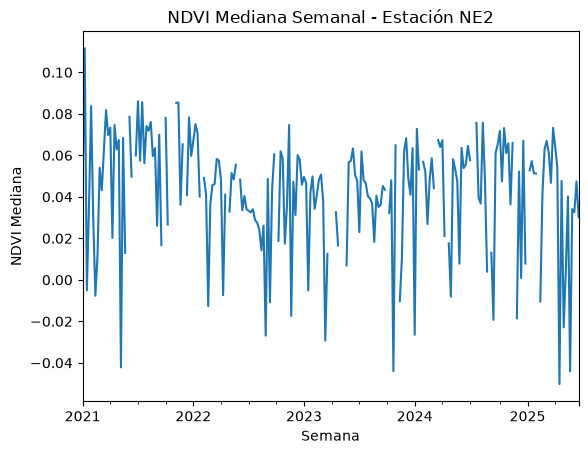

In [6]:
ndvi_NE2_semanal = ndvi_semanal[ndvi_semanal["estacion"] == "NE2"].set_index("semana")
ndvi_NE2_semanal['ndvi_mediana'].plot(kind='line', title='NDVI Mediana Semanal - Estación NE2', xlabel='Semana', ylabel='NDVI Mediana')

<Axes: title={'center': 'NDVI Mediana Semanal - Estación NE3'}, xlabel='Semana', ylabel='NDVI Mediana'>

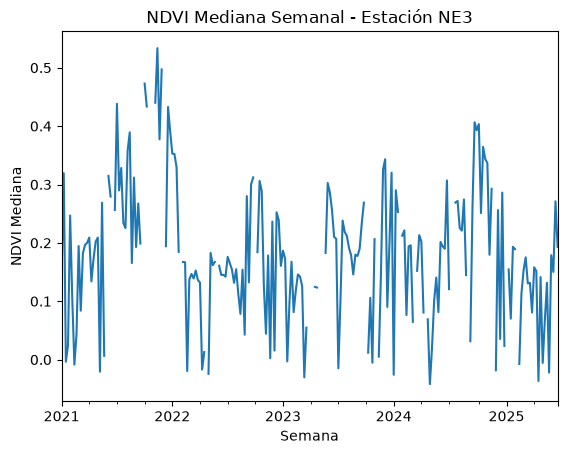

In [7]:
ndvi_NE3_semanal = ndvi_semanal[ndvi_semanal["estacion"] == "NE3"].set_index("semana")
ndvi_NE3_semanal['ndvi_mediana'].plot(kind='line', title='NDVI Mediana Semanal - Estación NE3', xlabel='Semana', ylabel='NDVI Mediana')

## Datos de PM10 de las estaciones

Se cargan las mediciones de PM10 de cada estación desde los archivos locales.

In [8]:
NE3 = pd.read_csv('../data_estaciones/BD_NE3.csv')  # Pesquería
NE2 = pd.read_csv('../data_estaciones/BD_NE2.csv')  # Apodaca

NE2['date'] = pd.to_datetime(NE2['date'])
NE3['date'] = pd.to_datetime(NE3['date'])

## Comparación semanal entre PM10 y NDVI

Se agregan las mediciones de PM10 por semana (con la misma definición de semana ISO que el NDVI), se combinan con `ndvi_semanal` y se escalan ambas series al rango [0, 1] para poder compararlas visualmente en la misma gráfica.

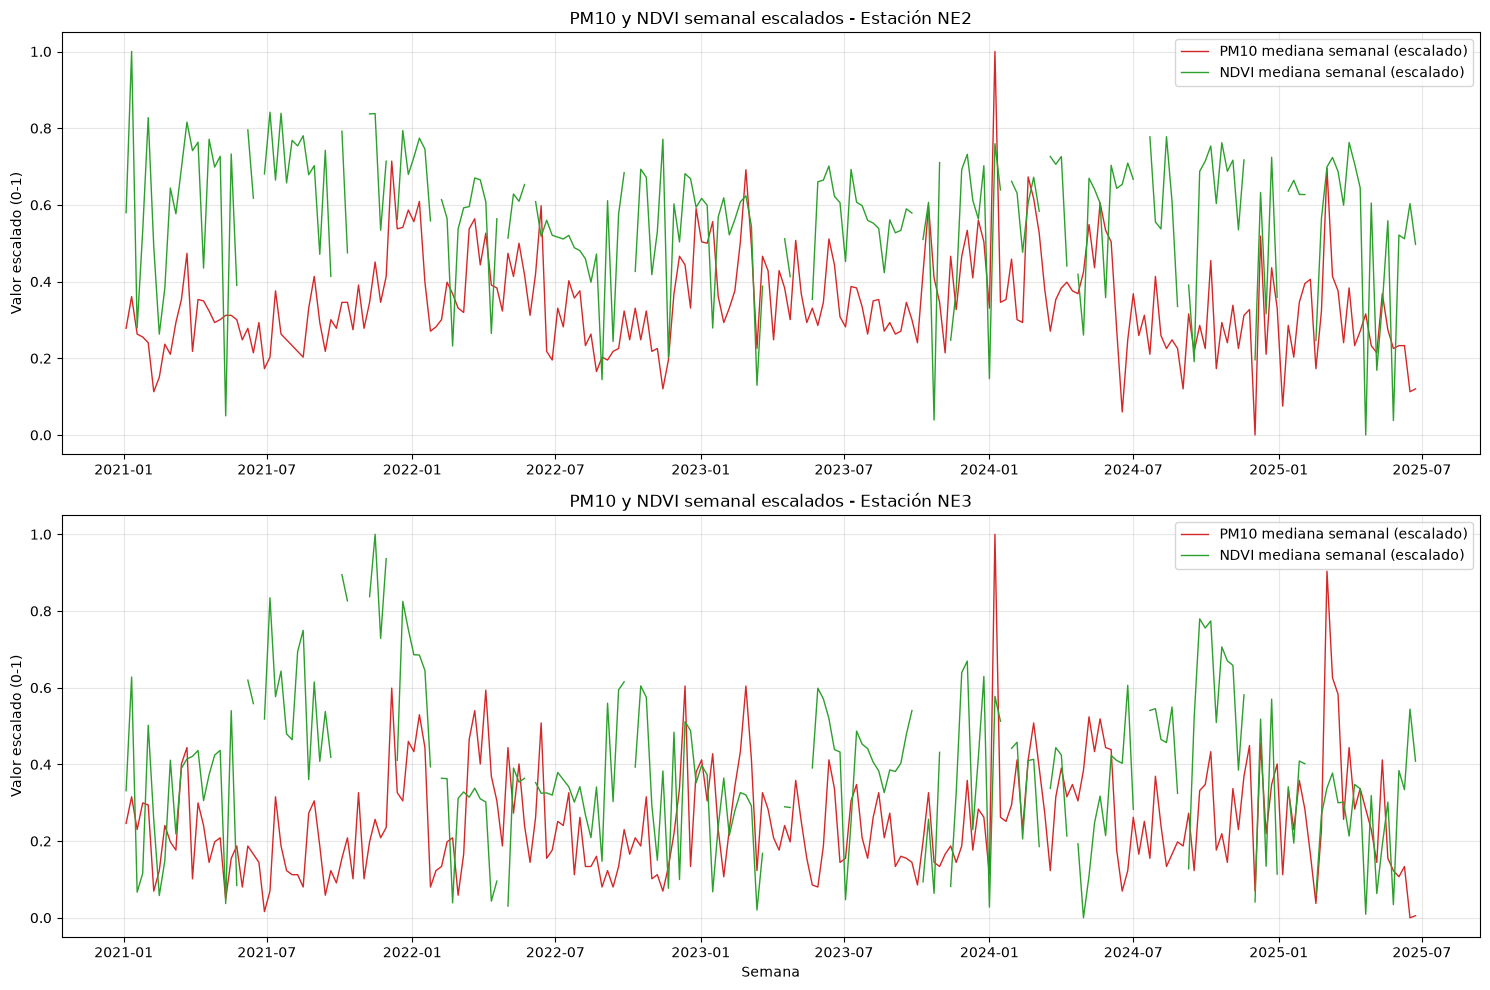

(      semana  pm10_mediana  ndvi_mediana  pm10_escalado  ndvi_escalado
 0 2021-01-04          54.0      0.043589       0.278195       0.579641
 1 2021-01-11          65.0      0.111654       0.360902       1.000000
 2 2021-01-18          52.0     -0.005069       0.263158       0.279136
 3 2021-01-25          51.0      0.035765       0.255639       0.531320
 4 2021-02-01          49.0      0.083736       0.240602       0.827580,
       semana  pm10_mediana  ndvi_mediana  pm10_escalado  ndvi_escalado
 0 2021-01-04          33.5      0.148724       0.245989       0.331333
 1 2021-01-11          40.0      0.319332       0.315508       0.627766
 2 2021-01-18          32.0     -0.003552       0.229947       0.066750
 3 2021-01-25          38.5      0.024677       0.299465       0.115798
 4 2021-02-01          38.0      0.246958       0.294118       0.502015)

In [9]:
def escalar_min_max(serie):
    """Escala una serie al intervalo [0, 1], ignorando valores faltantes."""
    minimo = serie.min()
    maximo = serie.max()
    if pd.isna(minimo) or minimo == maximo:
        return serie * 0
    return (serie - minimo) / (maximo - minimo)


def preparar_datos_estacion_semanal(datos_pm10, nombre_estacion):
    """Agrega PM10 por semana y lo combina con el NDVI semanal."""
    pm10_semanal = (
        datos_pm10.assign(
            semana=datos_pm10["date"].apply(semana_de),
            PM10=pd.to_numeric(datos_pm10["PM10"], errors="coerce"),
        )
        .groupby("semana", as_index=False)["PM10"]
        .median()
        .rename(columns={"PM10": "pm10_mediana"})
    )

    ndvi_estacion = ndvi_semanal.loc[
        ndvi_semanal["estacion"] == nombre_estacion,
        ["semana", "ndvi_mediana"],
    ]
    datos = pm10_semanal.merge(ndvi_estacion, on="semana", how="inner")
    datos = datos.sort_values("semana")
    datos["pm10_escalado"] = escalar_min_max(datos["pm10_mediana"])
    datos["ndvi_escalado"] = escalar_min_max(datos["ndvi_mediana"])
    return datos


serie_NE2_semanal = preparar_datos_estacion_semanal(NE2, "NE2")
serie_NE3_semanal = preparar_datos_estacion_semanal(NE3, "NE3")

fig, ejes = plt.subplots(2, 1, figsize=(15, 10), sharey=True)

for eje, datos, nombre_estacion in zip(
    ejes,
    [serie_NE2_semanal, serie_NE3_semanal],
    ["NE2", "NE3"],
):
    eje.plot(
        datos["semana"],
        datos["pm10_escalado"],
        label="PM10 mediana semanal (escalado)",
        color="tab:red",
        linewidth=1.0,
    )
    eje.plot(
        datos["semana"],
        datos["ndvi_escalado"],
        label="NDVI mediana semanal (escalado)",
        color="tab:green",
        linewidth=1.0,
    )
    eje.set_title(f"PM10 y NDVI semanal escalados - Estación {nombre_estacion}")
    eje.set_ylabel("Valor escalado (0-1)")
    eje.grid(True, alpha=0.3)
    eje.legend()

ejes[-1].set_xlabel("Semana")
plt.tight_layout()
plt.show()

serie_NE2_semanal.head(), serie_NE3_semanal.head()

### Correlación semanal entre PM10 y NDVI

In [10]:
# Correlación entre PM10 y NDVI semanal para la estación NE2
correlacion_NE2_semanal = serie_NE2_semanal["pm10_mediana"].corr(serie_NE2_semanal["ndvi_mediana"])

# Correlación entre PM10 y NDVI semanal para la estación NE3
correlacion_NE3_semanal = serie_NE3_semanal["pm10_mediana"].corr(serie_NE3_semanal["ndvi_mediana"])

correlacion_NE2_semanal, correlacion_NE3_semanal

(np.float64(0.20104342658925697), np.float64(0.022733894778760363))